# VP-SDE Diffusion

In [1]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

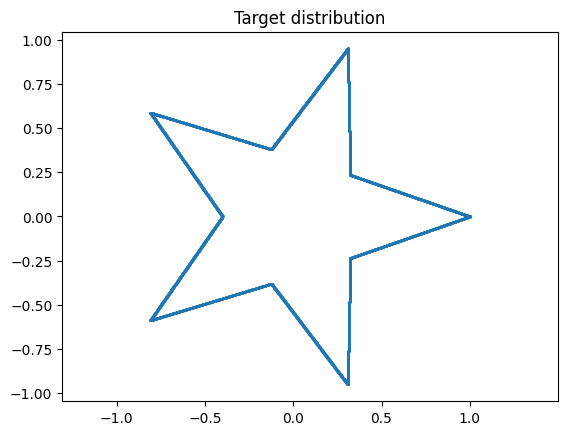

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1], s=1)
plt.title('Target distribution')
plt.axis('equal')
plt.show()

## VP-SDE schedules

In [3]:
def linear_alpha_bar(t, beta_min=0.1, beta_max=20.0):
    integral = beta_min * t + 0.5 * (beta_max - beta_min) * t ** 2
    return torch.clamp(torch.exp(-integral), min=1e-5, max=1.0 - 1e-5)

def linear_beta(t, beta_min=0.1, beta_max=20.0):
    return beta_min + (beta_max - beta_min) * t

def cosine_alpha_bar(t, s=0.008):
    angle = (t + s) / (1.0 + s) * math.pi / 2.0
    f0 = math.cos(s / (1.0 + s) * math.pi / 2.0) ** 2
    return torch.clamp(torch.cos(angle) ** 2 / f0, min=1e-5, max=1.0 - 1e-5)

def cosine_beta(t, s=0.008, beta_max=20.0):
    angle = (t + s) / (1.0 + s) * math.pi / 2.0
    beta = math.pi / (1.0 + s) * torch.tan(angle)
    return torch.clamp(beta, min=1e-6, max=beta_max)

SCHEDULES = {
    'linear': (linear_alpha_bar, linear_beta),
    'cosine': (cosine_alpha_bar, cosine_beta),
}

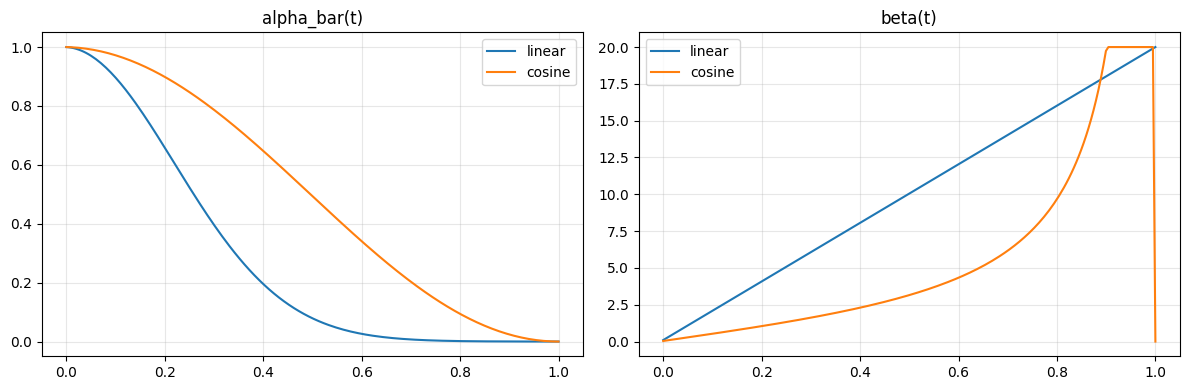

In [4]:
t_vals = torch.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, (ab_fn, b_fn) in SCHEDULES.items():
    axes[0].plot(t_vals.numpy(), ab_fn(t_vals).numpy(), label=name)
    axes[1].plot(t_vals.numpy(), b_fn(t_vals).numpy(), label=name)

axes[0].set_title('alpha_bar(t)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_title('beta(t)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Model and training

In [5]:
class Config:
    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000

class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [6]:
def weight_uniform(alpha_bar, beta, t):
    return torch.ones_like(t)

def weight_snr(alpha_bar, beta, t):
    snr = alpha_bar / (1.0 - alpha_bar + 1e-5)
    return torch.clamp(snr, max=5.0)

def weight_likelihood(alpha_bar, beta, t):
    return beta

WEIGHTS = {
    'uniform': weight_uniform,
    'snr': weight_snr,
    'likelihood': weight_likelihood,
}

In [7]:
class VPTrainer():
    def __init__(self, config, alpha_bar_fn, beta_fn, weight_fn):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
        self.alpha_bar_fn = alpha_bar_fn
        self.beta_fn = beta_fn
        self.weight_fn = weight_fn

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            t = torch.clamp(t, min=1e-5, max=1.0 - 1e-5)

            alpha_bar = self.alpha_bar_fn(t)
            beta = self.beta_fn(t)
            epsilon = torch.randn_like(batch)

            x_t = torch.sqrt(alpha_bar) * batch + torch.sqrt(1.0 - alpha_bar) * epsilon

            pred_epsilon = self.model(x_t, t)

            w = self.weight_fn(alpha_bar, beta, t)
            loss = (w * (pred_epsilon - epsilon) ** 2).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        losses = []
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            losses.append(loss)
            if n % 500 == 0:
                print(f'Epoch {n}: Loss = {loss:.6f}')
        return losses

In [8]:
def sample_vp(model, alpha_bar_fn, beta_fn, num_samples=1000, num_steps=1000):
    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / num_steps

        for i in range(num_steps):
            t = 1.0 - i * dt
            t = max(t, 1e-5)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            alpha_bar = alpha_bar_fn(t_tensor)
            beta = beta_fn(t_tensor)

            pred_epsilon = model(x, t_tensor)
            score = -pred_epsilon / torch.sqrt(1.0 - alpha_bar)

            drift = (0.5 * beta * x + beta * score) * dt

            if i < num_steps - 1:
                diffusion = torch.sqrt(beta * dt) * torch.randn_like(x)
            else:
                diffusion = torch.zeros_like(x)

            x = x + drift + diffusion

        return x.cpu().numpy()

## Experiments

In [9]:
config = Config()
experiments = {}

for sched_name in ['linear', 'cosine']:
    for weight_name in ['uniform', 'snr', 'likelihood']:
        exp_name = f'{sched_name}_{weight_name}'
        print(f'\n=== {exp_name} ===')

        ab_fn, b_fn = SCHEDULES[sched_name]
        w_fn = WEIGHTS[weight_name]

        trainer = VPTrainer(config, ab_fn, b_fn, w_fn)
        losses = trainer.run()

        samples = sample_vp(
            trainer.model, ab_fn, b_fn,
            num_samples=1000,
            num_steps=config.num_timesteps
        )

        experiments[exp_name] = {
            'model': trainer.model,
            'losses': losses,
            'samples': samples,
            'schedule': sched_name,
            'weight': weight_name,
        }
        print(f'Final loss: {losses[-1]:.6f}')


=== linear_uniform ===
Epoch 0: Loss = 0.864209
Epoch 500: Loss = 0.166001
Epoch 1000: Loss = 0.161822
Epoch 1500: Loss = 0.147769
Final loss: 0.152934

=== linear_snr ===
Epoch 0: Loss = 1.016817
Epoch 500: Loss = 0.565204
Epoch 1000: Loss = 0.563304
Epoch 1500: Loss = 0.544855
Final loss: 0.580957

=== linear_likelihood ===
Epoch 0: Loss = 8.389443
Epoch 500: Loss = 0.457002
Epoch 1000: Loss = 0.450010
Epoch 1500: Loss = 0.443463
Final loss: 0.435873

=== cosine_uniform ===
Epoch 0: Loss = 0.908682
Epoch 500: Loss = 0.315321
Epoch 1000: Loss = 0.289836
Epoch 1500: Loss = 0.284895
Final loss: 0.300136

=== cosine_snr ===
Epoch 0: Loss = 1.922237
Epoch 500: Loss = 1.210133
Epoch 1000: Loss = 1.114699
Epoch 1500: Loss = 1.140693
Final loss: 1.065502

=== cosine_likelihood ===
Epoch 0: Loss = 4.850614
Epoch 500: Loss = 0.444957
Epoch 1000: Loss = 0.443219
Epoch 1500: Loss = 0.444393
Final loss: 0.445017


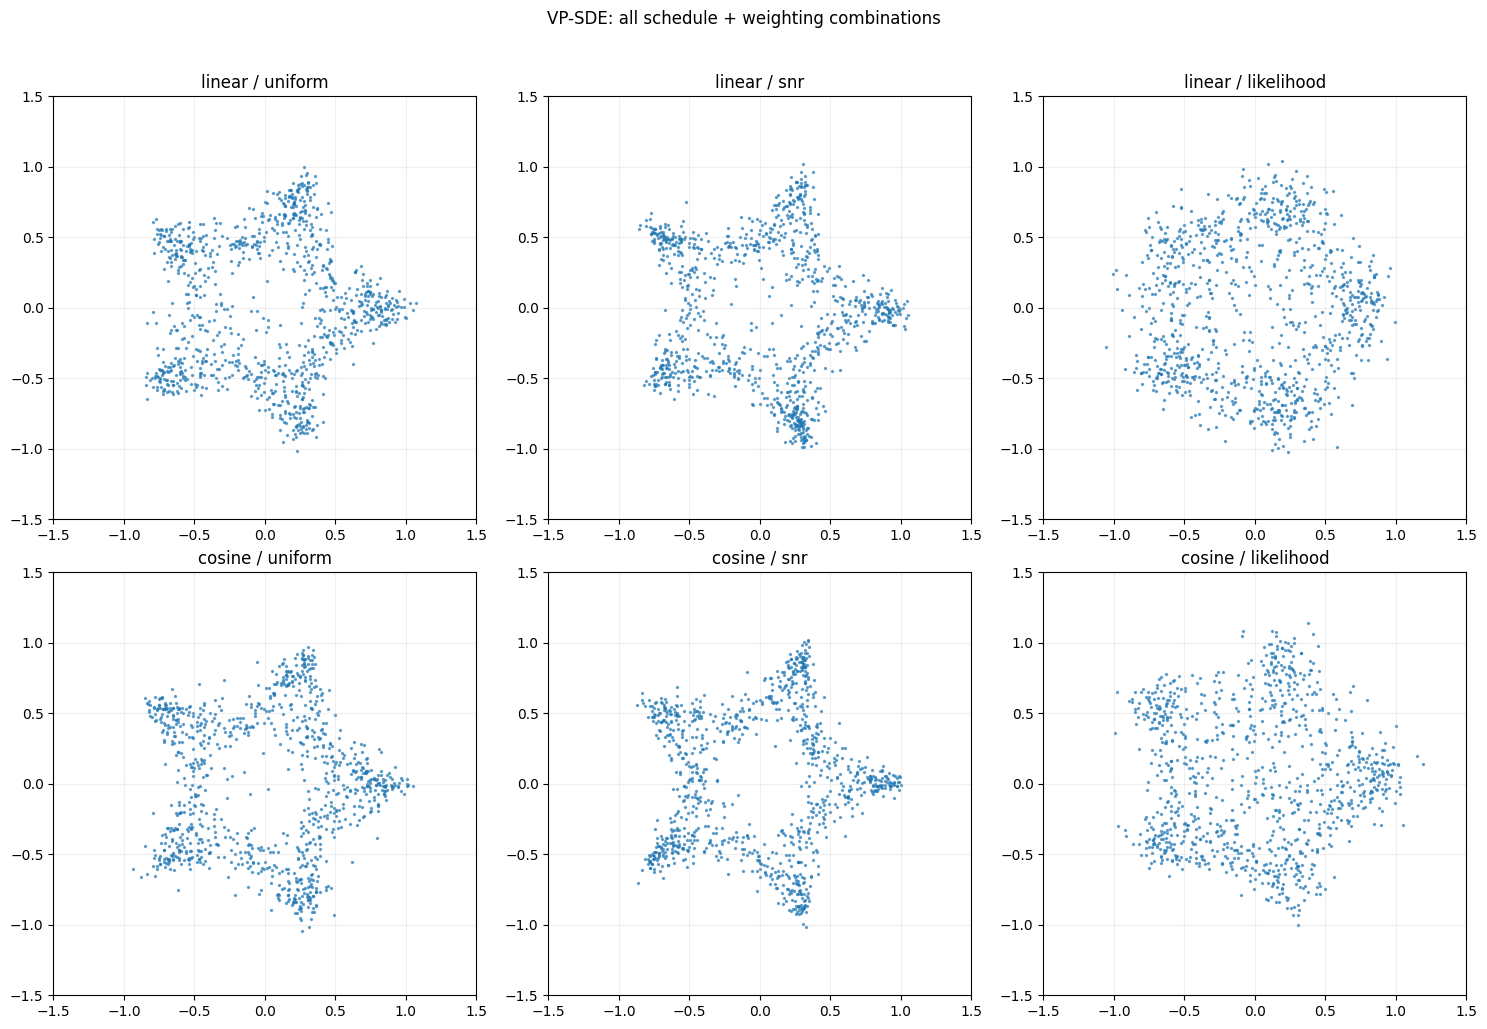

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
sched_names = ['linear', 'cosine']
weight_names = ['uniform', 'snr', 'likelihood']

for i, sched in enumerate(sched_names):
    for j, weight in enumerate(weight_names):
        exp = experiments[f'{sched}_{weight}']
        ax = axes[i][j]
        ax.scatter(exp['samples'][:, 0], exp['samples'][:, 1], s=2, alpha=0.6)
        ax.set_title(f'{sched} / {weight}')
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.2)

plt.suptitle('VP-SDE: all schedule + weighting combinations', y=1.02)
plt.tight_layout()
plt.show()

## Schedule comparison (linear vs cosine)

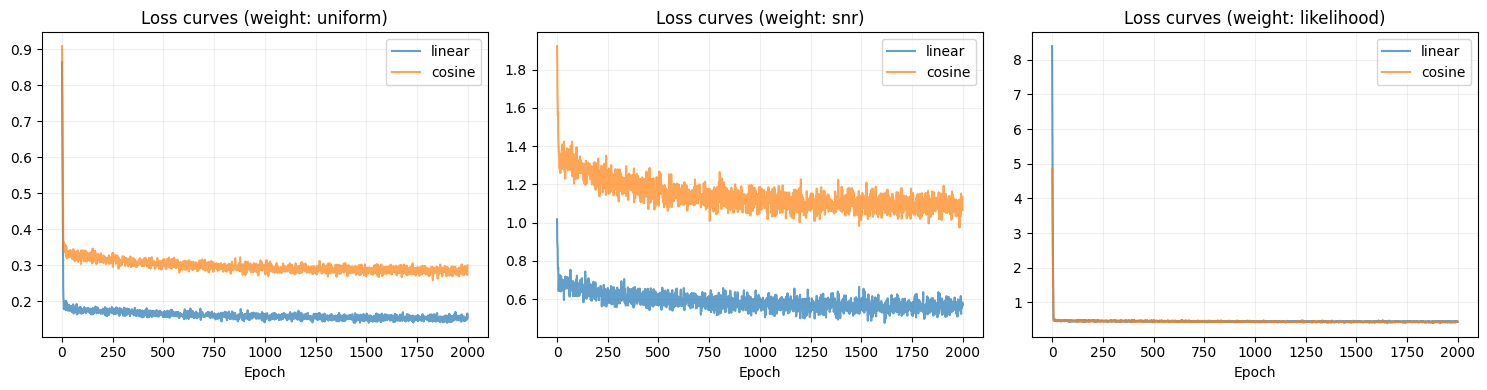

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for j, weight in enumerate(weight_names):
    ax = axes[j]
    for sched in sched_names:
        exp = experiments[f'{sched}_{weight}']
        ax.plot(exp['losses'], label=sched, alpha=0.7)
    ax.set_title(f'Loss curves (weight: {weight})')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

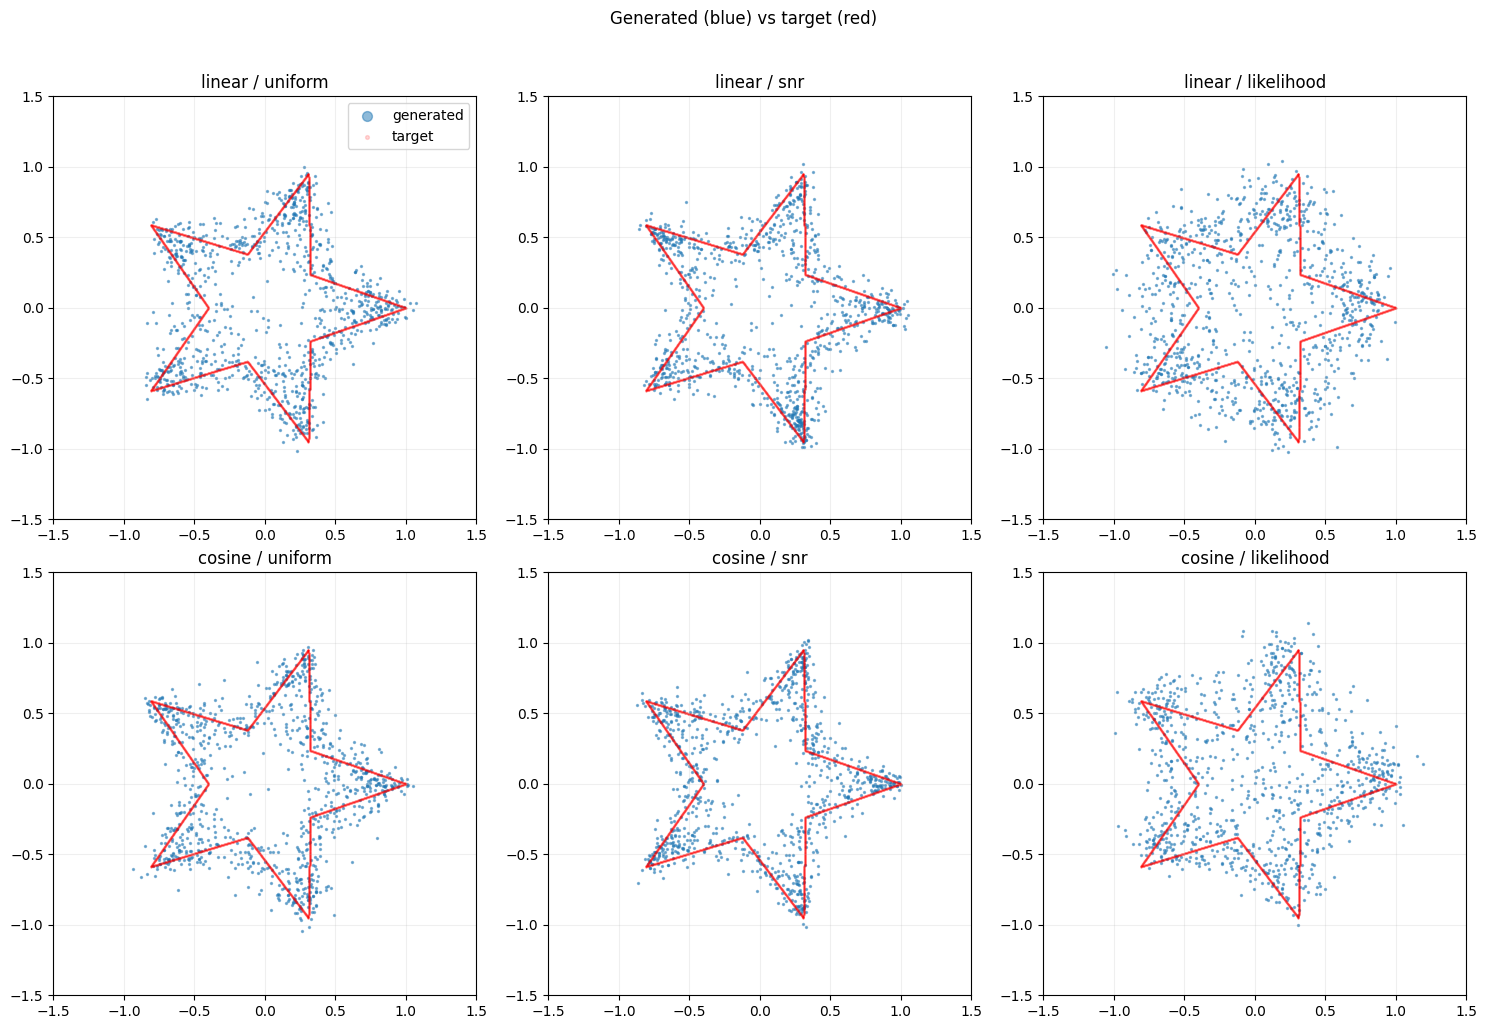

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for j, weight in enumerate(weight_names):
    for i, sched in enumerate(sched_names):
        exp = experiments[f'{sched}_{weight}']
        ax = axes[i][j]
        ax.scatter(exp['samples'][:, 0], exp['samples'][:, 1], s=2, alpha=0.5, label='generated')
        ax.scatter(s[:, 0], s[:, 1], s=0.3, alpha=0.15, color='red', label='target')
        ax.set_title(f'{sched} / {weight}')
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.2)
        if i == 0 and j == 0:
            ax.legend(markerscale=5)

plt.suptitle('Generated (blue) vs target (red)', y=1.02)
plt.tight_layout()
plt.show()

Косинусовое расписание обеспечивает более плавное зашумление данных по сравнению с линейным, что дает модели больше информации на промежуточных уровнях шума. Генерация формы звездочки более чёткая, особенно на кончиках лучей, где требуется точная локализация

## Loss reweighting comparison

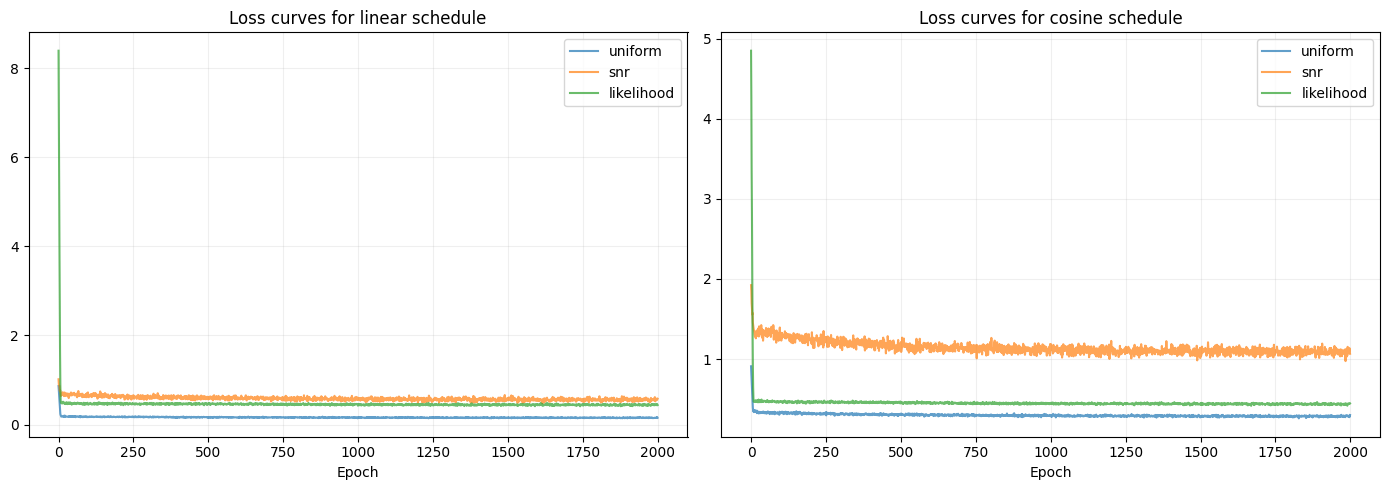

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, sched in enumerate(sched_names):
    ax = axes[i]
    for weight in weight_names:
        exp = experiments[f'{sched}_{weight}']
        ax.plot(exp['losses'], label=weight, alpha=0.7)
    ax.set_title(f'Loss curves for {sched} schedule')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

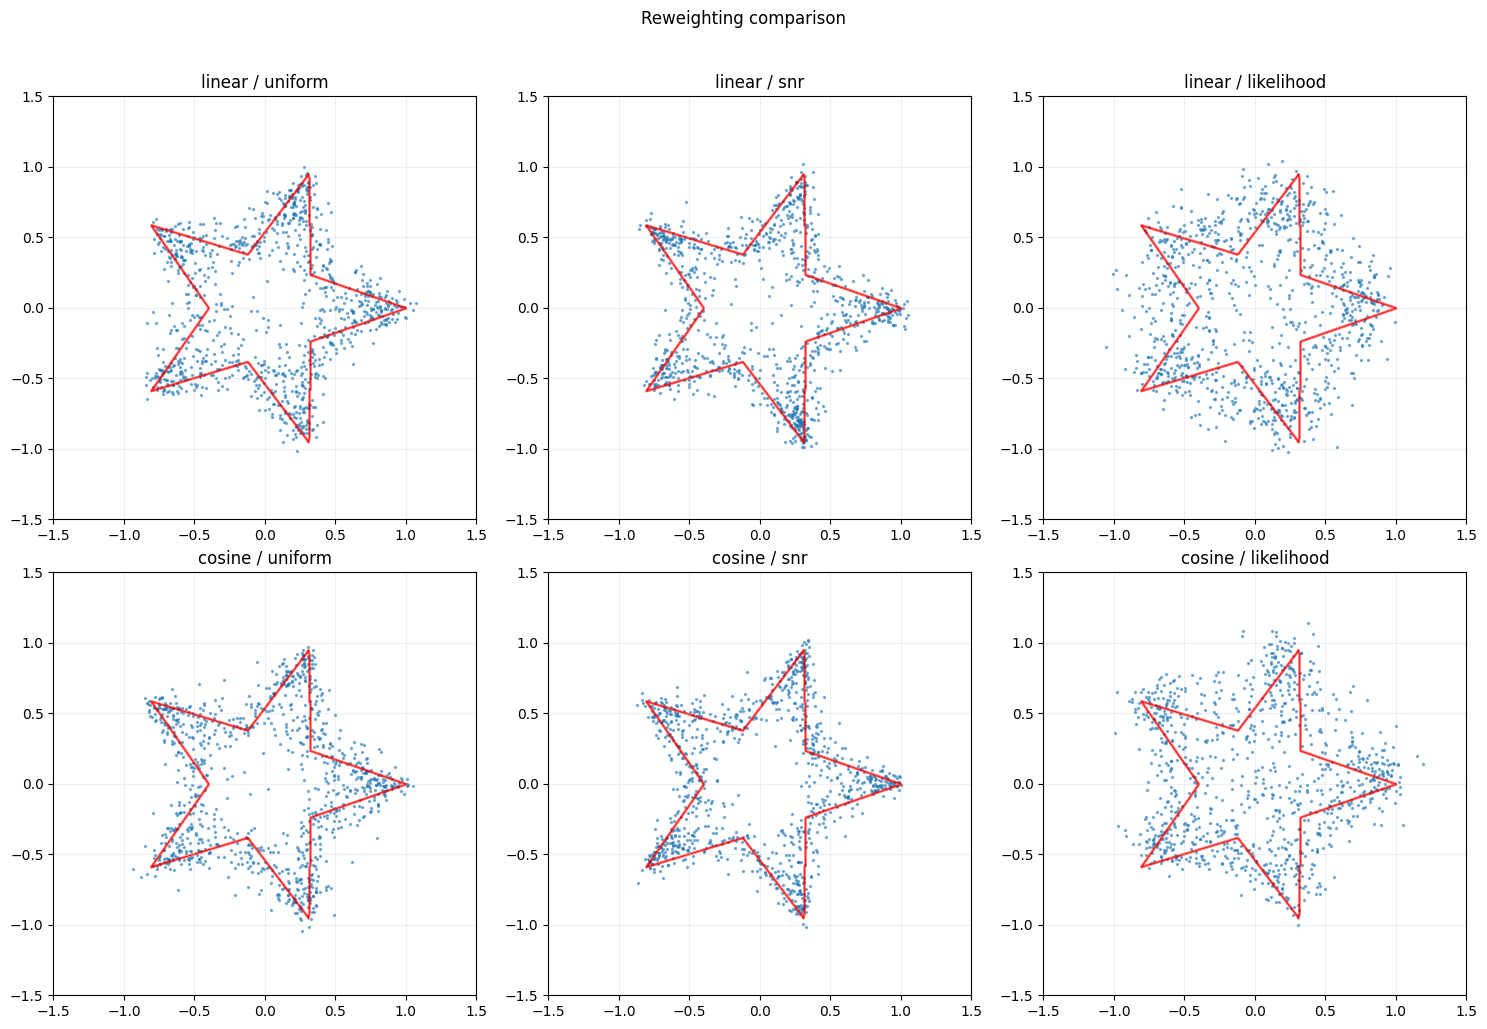

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, sched in enumerate(sched_names):
    for j, weight in enumerate(weight_names):
        exp = experiments[f'{sched}_{weight}']
        ax = axes[i][j]
        ax.scatter(exp['samples'][:, 0], exp['samples'][:, 1], s=2, alpha=0.5)
        ax.scatter(s[:, 0], s[:, 1], s=0.3, alpha=0.15, color='red')
        ax.set_title(f'{sched} / {weight}')
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.2)

plt.suptitle('Reweighting comparison', y=1.02)
plt.tight_layout()
plt.show()

Равномерное взвешивание дает стабильное обучение и хорошее базовое качество для простых 2D данных. Взвешивание по SNR усиливает обучение на мало зашумленных сэмплах и помогает с тонкими деталями формы, а взвешивание по beta акцентирует обучение на сильно зашумленных примерах и лучше улавливает общую структуру распределения

## Вывод

VP-SDE диффузия в целом успешно генерирует звездочку при всех шести комбинациях расписаний и перезвешиваний. Косинусовое расписание в целом дает более качественные результаты благодаря более равномерному распределению уровней шума по шкале времени, а выбор перезвешивания лосса позволяет управлять балансом между точностью мелких деталей и правильностью глобальной структуры